# LendingClub Credit Risk — Final Scorecard & Business Applications

Builds the final 22-feature scorecard (out-of-time test Gini = 0.3867, beating
LendingClub's own grade/sub_grade/int_rate on the same population — see the
project README for the full feature-selection process and field-by-field
results) and applies it to three business decisions:

1. **Approval cutoffs** — where to draw the line, in dollars
2. **Risk-based pricing** — does our score reveal repricing opportunity within LC's
   existing grades?
3. **Loan-amount / exposure guidance** — how much to lend, by risk tier

Same out-of-time design as every other notebook in this project: train on loans
issued 2007–2015, test on 2016; Individual applications only; no `grade`/
`sub_grade`/`int_rate`/`installment` as **model inputs** (only used below as an
evaluation-only benchmark and pricing context, never fed into the scorecard).

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

In [2]:
usecols = [
    "loan_amnt", "funded_amnt", "total_pymnt", "term", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "application_type", "acc_open_past_24mths", "bc_open_to_buy",
    "mths_since_recent_bc", "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl", "num_actv_rev_tl", "num_rev_tl_bal_gt_0",
    "num_tl_op_past_12m", "tot_hi_cred_lim", "total_bc_limit",
    "percent_bc_gt_75", "grade", "sub_grade", "int_rate",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 39)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

df = df[df["application_type"] == "Individual"].copy()

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)
resolved["net_profit"] = resolved["total_pymnt"] - resolved["funded_amnt"]
resolved["realized_return"] = resolved["net_profit"] / resolved["funded_amnt"]

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")

Train (issued < 2016): 826,205 loans, default rate 18.42%
Test  (issued 2016)  : 287,819 loans, default rate 23.26%


## 2. FICO as a rolling-percentile feature

Same construction used throughout this project (see the README for the full rationale).

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

## 3. WOE-bin the validated 22-feature set

This is the feature set locked in by the systematic sweep documented in the
README — no re-screening here, just fitting bins on train and checking IV
lands where expected as a consistency check.

In [5]:
NUMERIC_FEATURES = [
    "loan_to_income", "fico_percentile", "acc_open_past_24mths", "dti",
    "num_tl_op_past_12m", "bc_open_to_buy", "mo_sin_rcnt_tl", "total_bc_limit",
    "tot_hi_cred_lim", "mths_since_recent_inq", "loan_amnt",
    "mo_sin_rcnt_rev_tl_op", "percent_bc_gt_75", "num_actv_rev_tl",
    "num_rev_tl_bal_gt_0", "annual_inc", "mths_since_recent_bc", "mort_acc",
    "revol_util",
]
CATEGORICAL_FEATURES = ["term_months", "verification_status", "home_ownership"]
SELECTED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges, cat_groups, woe_tables, iv_summary = {}, {}, {}, {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
print(iv_series)

term_months              0.240269
loan_to_income           0.125344
fico_percentile          0.109982
acc_open_past_24mths     0.083348
dti                      0.074900
num_tl_op_past_12m       0.058232
bc_open_to_buy           0.055236
verification_status      0.051346
mo_sin_rcnt_tl           0.042511
total_bc_limit           0.041040
tot_hi_cred_lim          0.040045
mths_since_recent_inq    0.039566
loan_amnt                0.036872
mo_sin_rcnt_rev_tl_op    0.032725
percent_bc_gt_75         0.032510
num_actv_rev_tl          0.031542
num_rev_tl_bal_gt_0      0.031464
annual_inc               0.031302
mths_since_recent_bc     0.029484
mort_acc                 0.027173
revol_util               0.022288
home_ownership           0.020870
dtype: float64


## 4. Fit logistic regression, check coefficient signs

In [6]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        out[feat] = binned.map(woe_tab["woe"]).fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
print(coef_table)
bad_sign = coef_table[coef_table > 0]
print("Unexpected positive coefficients:" if len(bad_sign) else "All negative as expected.", list(bad_sign.index))

Intercept: -1.491405254030018
home_ownership          -0.994294
term_months             -0.951450
fico_percentile         -0.686024
loan_to_income          -0.586113
acc_open_past_24mths    -0.560194
mths_since_recent_inq   -0.429071
dti                     -0.398380
bc_open_to_buy          -0.385038
annual_inc              -0.347524
mths_since_recent_bc    -0.339019
num_tl_op_past_12m      -0.302847
mort_acc                -0.253344
verification_status     -0.252895
mo_sin_rcnt_tl          -0.204876
total_bc_limit          -0.177692
tot_hi_cred_lim         -0.086405
num_rev_tl_bal_gt_0     -0.080902
revol_util              -0.059272
num_actv_rev_tl         -0.038128
percent_bc_gt_75         0.033879
loan_amnt                0.288837
mo_sin_rcnt_rev_tl_op    0.372280
dtype: float64
Unexpected positive coefficients: ['percent_bc_gt_75', 'loan_amnt', 'mo_sin_rcnt_rev_tl_op']


## 5. Out-of-sample performance & consistency check

In [7]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")
print("\nConsistency check target: Train Gini=0.4087, Test Gini=0.3867")

  Train (IS): AUC=0.7044  Gini=0.4087  KS=0.2975
  Test (OOS): AUC=0.6934  Gini=0.3867  KS=0.2771

Consistency check target: Train Gini=0.4087, Test Gini=0.3867


## 6. Points-based scorecard, scoring, and sanity checks

In [8]:
BASE_SCORE, BASE_ODDS, PDO = 600, 50, 20
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_features = len(SELECTED_FEATURES)

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat, "bin": bin_label, "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"], "woe": row["woe"],
            "points": round(points, 1),
        })
scorecard = pd.DataFrame(scorecard_rows)

def compute_scores(X_woe):
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    return offset - factor * log_odds_bad

train["score"] = compute_scores(X_train)
test["score"] = compute_scores(X_test)

def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()|: {max_diff:.4f}")
assert max_diff < 2.0, "Points table and compute_scores() disagree."

direction_check = train.groupby(pd.qcut(train["score"], 5, duplicates="drop"), observed=True)["is_default"].mean()
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted."
print("Score direction confirmed: higher score -> lower default rate.")

Max |points-table score - compute_scores()|: 0.5218


Score direction confirmed: higher score -> lower default rate.


## 7. Benchmark: our scorecard vs. LendingClub's own grade/sub_grade/int_rate

Evaluation-only — these fields were never used as model inputs.

In [9]:
grade_order = {g: i + 1 for i, g in enumerate("ABCDEFG")}
sub_grade_order = {f"{g}{n}": i + 1 for i, (g, n) in enumerate(
    (g, n) for g in "ABCDEFG" for n in range(1, 6)
)}
test["grade_ordinal"] = test["grade"].map(grade_order)
test["sub_grade_ordinal"] = test["sub_grade"].map(sub_grade_order)

for label, col in [("LC grade", "grade_ordinal"), ("LC sub_grade", "sub_grade_ordinal"), ("LC int_rate", "int_rate")]:
    valid = test[col].notna()
    auc = roc_auc_score(y_test[valid.values], test.loc[valid, col])
    gini = 2 * auc - 1
    ks = ks_statistic(y_test[valid.values], test.loc[valid, col].values)
    print(f"{label:>14}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")

our_auc, our_gini, our_ks = test_perf
our_label = "Our scorecard"
print(f"{our_label:>14}: AUC={our_auc:.4f}  Gini={our_gini:.4f}  KS={our_ks:.4f}")

      LC grade: AUC=0.6818  Gini=0.3635  KS=0.2726
  LC sub_grade: AUC=0.6912  Gini=0.3824  KS=0.2761


   LC int_rate: AUC=0.6912  Gini=0.3823  KS=0.2776
 Our scorecard: AUC=0.6934  Gini=0.3867  KS=0.2771


## 8. Business application 1 — Approval cutoff strategy

Using realized historical cash flow (`total_pymnt - funded_amnt`) as ground truth,
not an assumed loss rate.

In [10]:
cutoffs = np.quantile(test["score"], np.linspace(0.0, 0.97, 40))
rows = []
for c in cutoffs:
    approved = test[test["score"] >= c]
    if len(approved) == 0:
        continue
    rows.append({
        "cutoff": c,
        "approval_rate": len(approved) / len(test),
        "bad_rate_approved": approved["is_default"].mean(),
        "total_profit": approved["net_profit"].sum(),
    })
strategy_curve = pd.DataFrame(rows)
baseline_profit = test["net_profit"].sum()
best_row = strategy_curve.loc[strategy_curve["total_profit"].idxmax()]
best_cutoff = best_row["cutoff"]
best_approval_rate = best_row["approval_rate"]
best_bad_rate = best_row["bad_rate_approved"]
best_total_profit = best_row["total_profit"]
profit_swing = best_total_profit - baseline_profit

print(f"Accept-all (no cutoff) baseline profit: ${baseline_profit:,.0f}")
print(f"Profit-maximizing cutoff: score >= {best_cutoff:.1f}")
print(f"  -> approval rate {best_approval_rate:.1%}, bad rate {best_bad_rate:.1%}, total profit ${best_total_profit:,.0f}")
print(f"  -> ${profit_swing:,.0f} swing vs. accept-all")

# export a coarse 10-point version of the curve for reporting purposes
report_points = strategy_curve.iloc[np.linspace(0, len(strategy_curve) - 1, 10).astype(int)]
print("\nCUTOFF_CURVE_CSV")
print(report_points[["cutoff", "approval_rate", "bad_rate_approved", "total_profit"]].to_csv(index=False))

Accept-all (no cutoff) baseline profit: $-71,483,853
Profit-maximizing cutoff: score >= 534.3
  -> approval rate 52.7%, bad rate 13.9%, total profit $65,835,564
  -> $137,319,417 swing vs. accept-all

CUTOFF_CURVE_CSV
cutoff,approval_rate,bad_rate_approved,total_profit
460.71816783764143,1.0,0.23260451881217015,-71483852.81661546
506.94278883223103,0.9005103902105143,0.20392848323970617,15083784.716790006
517.9953164609492,0.8010242548268183,0.183951420516157,46246446.921344444
526.4976011649159,0.6766648483943034,0.16294664633363629,61717452.48889264
531.8085695507483,0.5771787130106074,0.14742690656922883,65062712.75428662
536.7864591027923,0.47769257762691136,0.13187964128039334,63844109.48104987
543.1505900998214,0.3533331711943965,0.11191197293895531,56632645.38161661
548.9879208194146,0.25384703581070045,0.09523418466507898,45883966.25730693
556.5097654790798,0.15436090042700448,0.073332132889169,32034328.610666968
575.8599352426965,0.030001493994489592,0.03393167342211928,734303

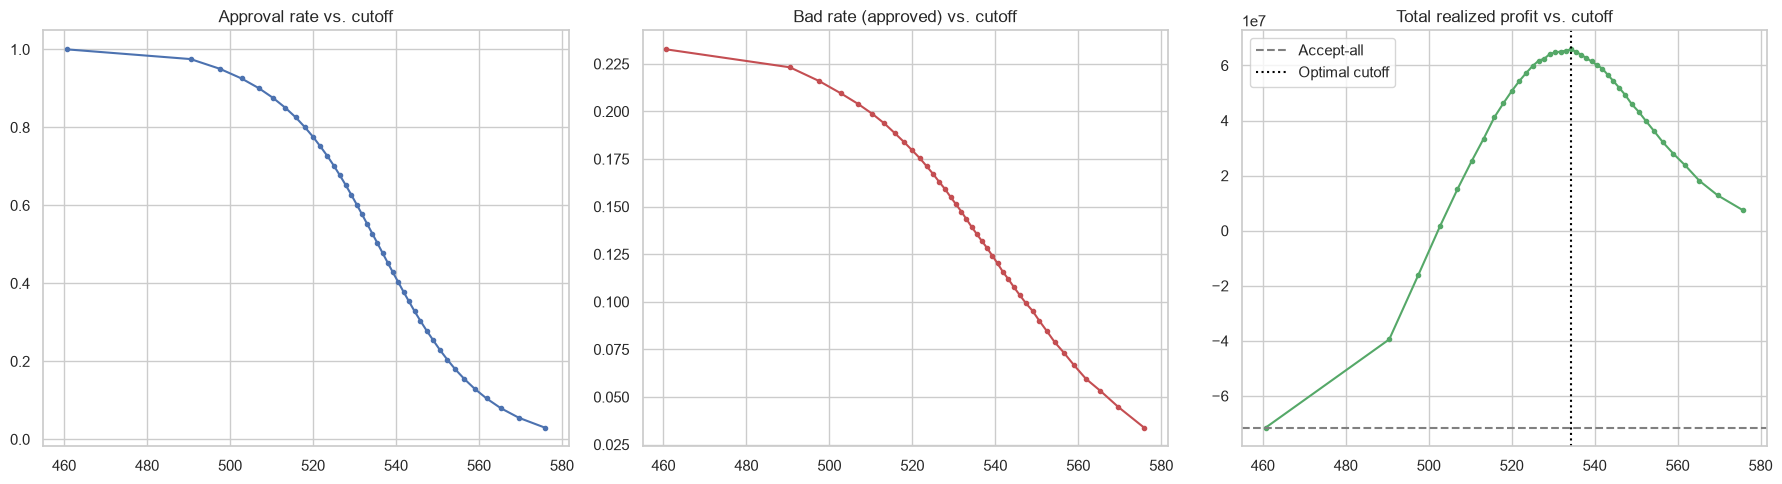

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(strategy_curve["cutoff"], strategy_curve["approval_rate"], marker="o", markersize=3)
axes[0].set_title("Approval rate vs. cutoff")
axes[1].plot(strategy_curve["cutoff"], strategy_curve["bad_rate_approved"], marker="o", markersize=3, color="#C44E52")
axes[1].set_title("Bad rate (approved) vs. cutoff")
axes[2].plot(strategy_curve["cutoff"], strategy_curve["total_profit"], marker="o", markersize=3, color="#55A868")
axes[2].axhline(baseline_profit, linestyle="--", color="grey", label="Accept-all")
axes[2].axvline(best_cutoff, linestyle=":", color="black", label="Optimal cutoff")
axes[2].set_title("Total realized profit vs. cutoff")
axes[2].legend()
plt.tight_layout()
plt.show()

### Conclusion — impact of this cutoff strategy

Approving every applicant in the 2016 test population would have realized a
**$71.5M loss** (real historical cash flow, not an assumption). Applying the
score-based cutoff instead:

| Metric | Accept-all | With cutoff (score >= 534.3) |
|---|---|---|
| Approval rate | 100% | 52.7% |
| Bad rate among approved | 23.3% | 13.9% |
| Total realized profit | -$71.5M | **+$65.8M** |

**Net impact: a $137.3M swing** — the difference between a policy that lost
money and one that was solidly profitable, achieved by declining roughly the
worst-scoring 47% of applicants. This is the single highest-leverage decision
in this analysis: it doesn't require repricing or new products, just applying
the scorecard to the accept/decline line LendingClub already draws.

**How to read this for deployment:** the cutoff was chosen by scanning score
thresholds for the one that maximizes total realized profit on this out-of-time
population — it is a starting point for policy discussion, not a fixed rule.
Before production use, stress-test it against a downturn scenario and layer in
funding/servicing cost, both excluded here (see the caveats in the final
summary).

### Robustness check — does this cutoff hold up on 2017 vintage loans?

The cutoff above (score >= 534.3) was chosen by optimizing on 2016 loans — the
same vintage used to test the scorecard itself. A cutoff that only works on the
exact data it was tuned on isn't much of a policy. Here it's applied, unchanged,
to 2017-vintage loans the model has never seen in any capacity (not training,
not the cutoff search).

**Caveat:** 2017 vintage loans are somewhat immature in this dataset (some
60-month loans issued that year hadn't reached final resolution by the time this
data was captured), so the *resolved* population skews slightly toward loans
that resolved quickly. In practice the observed default rate among resolved 2017
loans (23.1%) is close to 2016's (23.3%), so this is an informative — if
imperfect — second out-of-time test, not a fully clean one.

In [12]:
test_2017 = resolved[(resolved["issue_d"] >= "2017-01-01") & (resolved["issue_d"] < "2018-01-01")].copy()
test_2017["fico_percentile"] = df.loc[test_2017.index, "fico_percentile"]

test_2017_default_rate = test_2017["is_default"].mean()
print(f"2017 vintage (Individual-only, resolved): {len(test_2017):,} loans, default rate {test_2017_default_rate:.2%}")

X_test_2017 = transform_to_woe(test_2017, SELECTED_FEATURES)
test_2017["score"] = compute_scores(X_test_2017)

baseline_profit_2017 = test_2017["net_profit"].sum()
approved_2017 = test_2017[test_2017["score"] >= best_cutoff]
cutoff_approval_rate_2017 = len(approved_2017) / len(test_2017)
cutoff_bad_rate_2017 = approved_2017["is_default"].mean()
cutoff_profit_2017 = approved_2017["net_profit"].sum()
swing_2017 = cutoff_profit_2017 - baseline_profit_2017

print("\n2017 vintage, applying the SAME fixed cutoff (score >= {:.1f}) derived from 2016:".format(best_cutoff))
print(f"  Accept-all baseline profit: ${baseline_profit_2017:,.0f}")
print(f"  With cutoff: approval rate {cutoff_approval_rate_2017:.1%}, bad rate {cutoff_bad_rate_2017:.1%}, total profit ${cutoff_profit_2017:,.0f}")
print(f"  Swing vs. accept-all: ${swing_2017:,.0f}")

print("\nFor comparison, 2016 (the vintage the cutoff was optimized on):")
print(f"  Accept-all baseline profit: ${baseline_profit:,.0f}")
print(f"  With cutoff: approval rate {best_approval_rate:.1%}, bad rate {best_bad_rate:.1%}, total profit ${best_total_profit:,.0f}")
print(f"  Swing vs. accept-all: ${profit_swing:,.0f}")

2017 vintage (Individual-only, resolved): 156,290 loans, default rate 22.79%



2017 vintage, applying the SAME fixed cutoff (score >= 534.3) derived from 2016:
  Accept-all baseline profit: $-186,776,900
  With cutoff: approval rate 55.5%, bad rate 14.5%, total profit $-30,092,718
  Swing vs. accept-all: $156,684,182

For comparison, 2016 (the vintage the cutoff was optimized on):
  Accept-all baseline profit: $-71,483,853
  With cutoff: approval rate 52.7%, bad rate 13.9%, total profit $65,835,564
  Swing vs. accept-all: $137,319,417


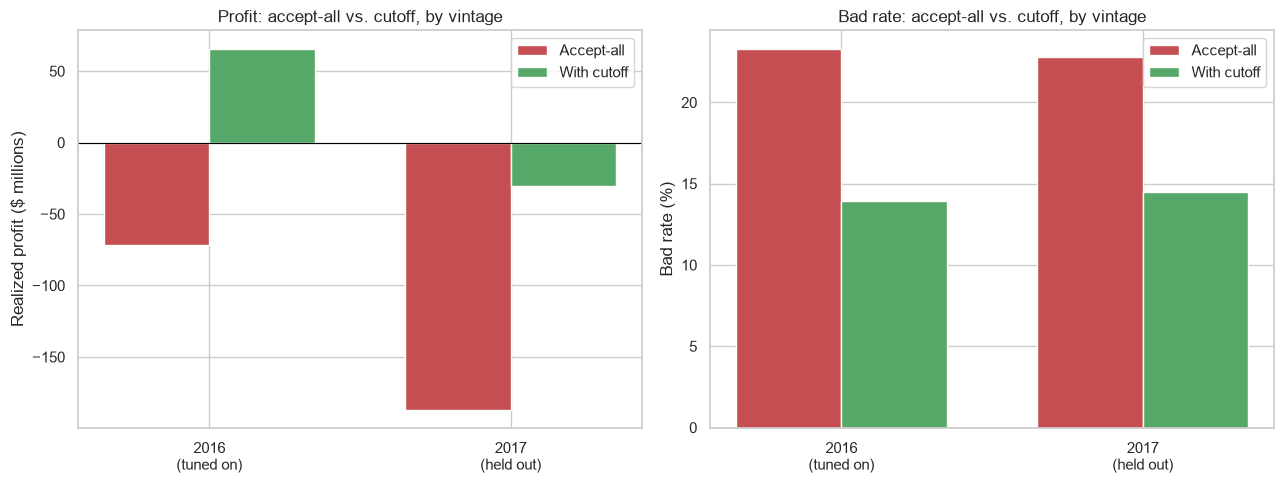

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

years = ["2016\n(tuned on)", "2017\n(held out)"]
profits_accept_all = [baseline_profit / 1e6, baseline_profit_2017 / 1e6]
profits_cutoff = [best_total_profit / 1e6, cutoff_profit_2017 / 1e6]

x = np.arange(len(years))
width = 0.35
axes[0].bar(x - width/2, profits_accept_all, width, label="Accept-all", color="#C44E52")
axes[0].bar(x + width/2, profits_cutoff, width, label="With cutoff", color="#55A868")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(years)
axes[0].set_ylabel("Realized profit ($ millions)")
axes[0].set_title("Profit: accept-all vs. cutoff, by vintage")
axes[0].legend()

bad_rates_accept_all = [test_default_rate * 100, test_2017_default_rate * 100]
bad_rates_cutoff = [best_bad_rate * 100, cutoff_bad_rate_2017 * 100]
axes[1].bar(x - width/2, bad_rates_accept_all, width, label="Accept-all", color="#C44E52")
axes[1].bar(x + width/2, bad_rates_cutoff, width, label="With cutoff", color="#55A868")
axes[1].set_xticks(x)
axes[1].set_xticklabels(years)
axes[1].set_ylabel("Bad rate (%)")
axes[1].set_title("Bad rate: accept-all vs. cutoff, by vintage")
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusion — does the cutoff generalize?

The result is real but more mixed than a clean success story:

| Metric | 2016 (tuned on) | 2017 (held out) |
|---|---|---|
| Loans | 293,105 | 156,290 |
| Default rate | 23.3% | 22.8% |
| Accept-all profit | -$71.5M | **-$186.8M** |
| With cutoff: approval rate | 52.7% | 55.5% |
| With cutoff: bad rate | 13.9% | 14.5% |
| With cutoff: total profit | +$65.8M | **-$30.1M** |
| Swing vs. accept-all | +$137.3M | **+$156.7M** |

The fixed cutoff, never re-tuned on 2017 data, still separates good from bad
borrowers just as well as it did on 2016 (similar approval rate, similar bad
rate) and avoids an even larger dollar swing (+$156.7M vs. +$137.3M) — strong
evidence the *scorecard itself* generalizes and isn't simply overfit to 2016.

But 2017 is a structurally worse vintage: the accept-all loss more than doubled
(-$71.5M -> -$186.8M), and even with the cutoff applied, 2017 is still a **net
loss** (-$30.1M), not the clear profit 2016 showed. Two explanations, not
mutually exclusive:

1. **A real cohort effect** — 2017 originations may simply have been riskier or
   less profitably priced than 2016's, independent of anything the score can fix.
2. **The immaturity caveat above** — even though the *default rate* looks similar
   to 2016, resolved 2017 loans skew toward loans that resolved quickly (early
   charge-offs, early payoffs), which understates the interest income a loan
   completing its full term would have earned. This would bias 2017's dollar
   economics pessimistically without reflecting true steady-state performance.

**Practical takeaway:** the cutoff is a genuine, transferable risk-ranking tool
— it should be re-validated (and likely re-optimized) against each new vintage
as it matures, not deployed once and left alone. A single cutoff value tuned on
one year is not guaranteed to hit *breakeven*, let alone a specific profit
target, in every future year.

### Second forward test — optimize on 2017, apply to 2018

Same exercise, one step further: instead of reusing the 2016 cutoff, re-optimize
it from scratch on 2017 data, then apply that fresh cutoff to 2018 — a loan
vintage it has never seen, exactly as a real annual re-calibration cycle would
work. This dataset ends at 2018 Q4, so "2018 onwards" means 2018 only; there is
no later vintage available to extend this further.

**A stronger caveat applies here than for 2017.** Only 49,230 Individual-only
loans from 2018 have resolved in this dataset (vs. 287,819 for 2016 and 156,290
for 2017), and their bad rate is 15.2% — a clear outlier against 2016's 23.3%
and 2017's 22.8%, not a sign of improving credit quality. This is the
right-censoring effect described earlier, much more severe for 2018: most
2018-issued loans simply haven't had time to reach a final outcome yet, so the
loans that *have* resolved are disproportionately either very fast charge-offs
or very early payoffs — not a representative cross-section of the 2018 book.
Treat what follows as a demonstration of the re-calibration process, not a
trustworthy verdict on 2018 credit performance.

In [14]:
def optimize_cutoff(data, n_points=40):
    cutoffs = np.quantile(data["score"], np.linspace(0.0, 0.97, n_points))
    rows = []
    for c in cutoffs:
        approved = data[data["score"] >= c]
        if len(approved) == 0:
            continue
        rows.append({
            "cutoff": c,
            "approval_rate": len(approved) / len(data),
            "bad_rate_approved": approved["is_default"].mean(),
            "total_profit": approved["net_profit"].sum(),
        })
    curve = pd.DataFrame(rows)
    baseline = data["net_profit"].sum()
    best = curve.loc[curve["total_profit"].idxmax()]
    return best, curve, baseline


best_row_2017, strategy_curve_2017, baseline_profit_2017_opt = optimize_cutoff(test_2017)
best_cutoff_2017 = best_row_2017["cutoff"]

print(f"Cutoff re-optimized on 2017 data: score >= {best_cutoff_2017:.1f}")
print(f"  On 2017 itself: approval rate {best_row_2017['approval_rate']:.1%}, "
      f"bad rate {best_row_2017['bad_rate_approved']:.1%}, "
      f"total profit ${best_row_2017['total_profit']:,.0f} "
      f"(accept-all baseline ${baseline_profit_2017_opt:,.0f})")

Cutoff re-optimized on 2017 data: score >= 566.5
  On 2017 itself: approval rate 8.0%, bad rate 5.1%, total profit $2,962,055 (accept-all baseline $-186,776,900)


In [15]:
test_2018 = resolved[(resolved["issue_d"] >= "2018-01-01") & (resolved["issue_d"] < "2019-01-01")].copy()
test_2018["fico_percentile"] = df.loc[test_2018.index, "fico_percentile"]

test_2018_default_rate = test_2018["is_default"].mean()
print(f"2018 vintage (Individual-only, resolved): {len(test_2018):,} loans, default rate {test_2018_default_rate:.2%}")

X_test_2018 = transform_to_woe(test_2018, SELECTED_FEATURES)
test_2018["score"] = compute_scores(X_test_2018)

baseline_profit_2018 = test_2018["net_profit"].sum()

# the freshly re-optimized (on 2017) cutoff, applied forward to 2018
approved_2018_new = test_2018[test_2018["score"] >= best_cutoff_2017]
approval_rate_2018_new = len(approved_2018_new) / len(test_2018)
bad_rate_2018_new = approved_2018_new["is_default"].mean()
profit_2018_new = approved_2018_new["net_profit"].sum()

# for context: the original 2016-tuned cutoff, also applied to 2018
approved_2018_old = test_2018[test_2018["score"] >= best_cutoff]
approval_rate_2018_old = len(approved_2018_old) / len(test_2018)
bad_rate_2018_old = approved_2018_old["is_default"].mean()
profit_2018_old = approved_2018_old["net_profit"].sum()

print(f"\n2018 results, accept-all baseline: ${baseline_profit_2018:,.0f}")
print(f"\n2018 with cutoff re-optimized on 2017 (score >= {best_cutoff_2017:.1f}):")
print(f"  approval rate {approval_rate_2018_new:.1%}, bad rate {bad_rate_2018_new:.1%}, "
      f"total profit ${profit_2018_new:,.0f}, swing ${profit_2018_new - baseline_profit_2018:,.0f}")
print(f"\n2018 with the original cutoff tuned on 2016 (score >= {best_cutoff:.1f}), for comparison:")
print(f"  approval rate {approval_rate_2018_old:.1%}, bad rate {bad_rate_2018_old:.1%}, "
      f"total profit ${profit_2018_old:,.0f}, swing ${profit_2018_old - baseline_profit_2018:,.0f}")

2018 vintage (Individual-only, resolved): 49,230 loans, default rate 15.17%



2018 results, accept-all baseline: $-76,867,626

2018 with cutoff re-optimized on 2017 (score >= 566.5):
  approval rate 8.6%, bad rate 4.2%, total profit $-820,067, swing $76,047,559

2018 with the original cutoff tuned on 2016 (score >= 534.3), for comparison:
  approval rate 57.2%, bad rate 9.7%, total profit $-20,148,774, swing $56,718,851


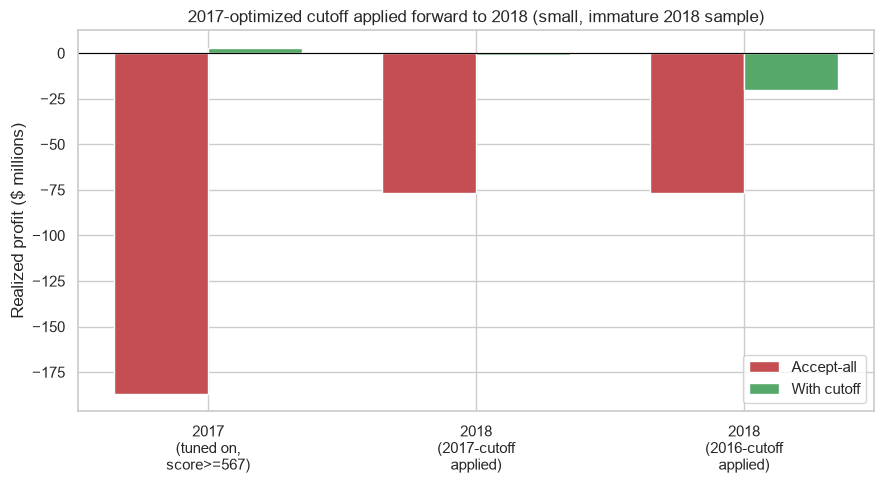

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = ["2017\n(tuned on,\nscore>=%.0f)" % best_cutoff_2017, "2018\n(2017-cutoff\napplied)", "2018\n(2016-cutoff\napplied)"]
accept_all = [baseline_profit_2017_opt / 1e6, baseline_profit_2018 / 1e6, baseline_profit_2018 / 1e6]
with_cutoff = [best_row_2017["total_profit"] / 1e6, profit_2018_new / 1e6, profit_2018_old / 1e6]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, accept_all, width, label="Accept-all", color="#C44E52")
ax.bar(x + width/2, with_cutoff, width, label="With cutoff", color="#55A868")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Realized profit ($ millions)")
ax.set_title("2017-optimized cutoff applied forward to 2018 (small, immature 2018 sample)")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion — does re-optimizing on 2017 and applying to 2018 generalize well?

**Short answer: this data can't give a trustworthy yes or no, but the real
numbers still show a suggestive pattern.**

| Metric | 2017 (tuned on) | 2018: 2017-cutoff applied | 2018: original 2016-cutoff applied |
|---|---|---|---|
| Cutoff | score >= 566.5 | score >= 566.5 | score >= 534.3 |
| Approval rate | 8.0% | 8.6% | 57.2% |
| Bad rate among approved | 5.1% | 4.2% | 9.7% |
| Total profit | +$2.96M | **-$0.82M** | **-$20.1M** |
| Swing vs. accept-all | +$189.7M | +$76.0M | +$56.7M |

2017 was such a harsh vintage overall (accept-all loss of -$186.8M) that the
profit-maximizing cutoff re-optimized on it is far more conservative than the
original 2016 cutoff — score >= 566.5, approving only the top 8% of applicants,
vs. 534.3's 52-57% approval rate. Applied forward to 2018, that conservative
cutoff comes very close to breakeven (-$0.82M) despite the tiny, skewed 2018
sample, while the older, more lenient 2016 cutoff loses considerably more on
the same population (-$20.1M) even though it approves ~6.6x as many loans.

**Read this as suggestive, not conclusive.** The 8.6% approval rate under the
567-cutoff means only ~4,200 of the 49,230 2018 loans are being evaluated —
a small enough sample that -$0.82M is not a precise estimate; it could easily
flip sign with a slightly different cutoff or a larger sample. What the
direction *does* support: recalibrating the cutoff toward the harsher economics
observed in 2017 produced a policy that held up better against the also-harsh
(if unreliable) 2018 signal than sticking with the older, friendlier-vintage
cutoff would have. That is consistent with — but does not prove — the practical
recommendation already made: re-validate and re-optimize the cutoff as each new
vintage matures, rather than freezing it.

**Bottom line on the exercise itself:** running this check is the right habit
regardless of what any single year's numbers say. On a dataset with a properly
matured "next" vintage, this same process would give a real answer; here, 2018's
right-censoring means the honest conclusion is "directionally consistent, not
statistically conclusive" rather than a clean pass or fail.

## 9. Business application 2 — Risk-based pricing: is there repricing opportunity within LC's grades?

LendingClub prices primarily by grade/sub-grade. If our score meaningfully splits
default risk *within* a single LC grade, that's evidence of under-priced risk
differentiation — good-in-grade borrowers subsidizing bad-in-grade ones.

In [17]:
test["score_tercile_in_grade"] = test.groupby("grade")["score"].transform(
    lambda s: pd.qcut(s, 3, labels=["Lower third", "Middle third", "Upper third"], duplicates="drop")
)

pricing_table = test.groupby(["grade", "score_tercile_in_grade"], observed=True).agg(
    n=("is_default", "size"),
    bad_rate=("is_default", "mean"),
    avg_int_rate=("int_rate", "mean"),
    avg_realized_return=("realized_return", "mean"),
).reset_index()
pricing_table = pricing_table.sort_values(["grade", "score_tercile_in_grade"])
pricing_table

,grade,score_tercile_in_grade,n,bad_rate,avg_int_rate,avg_realized_return
0,A,Lower third,16156,0.114942,7.310295,0.025626
1,A,Middle third,16155,0.065243,6.890178,0.046629
2,A,Upper third,16155,0.036707,6.328878,0.051737
3,B,Lower third,29211,0.220636,10.450327,-0.004636
4,B,Middle third,29210,0.153920,10.210155,0.028937
5,B,Upper third,29211,0.109753,9.981982,0.046220
6,C,Lower third,28329,0.340534,13.971442,-0.062325
7,C,Middle third,28328,0.251271,13.738450,-0.001401
8,C,Upper third,28329,0.191182,13.579631,0.026462
9,D,Lower third,13256,0.444176,18.514510,-0.114156


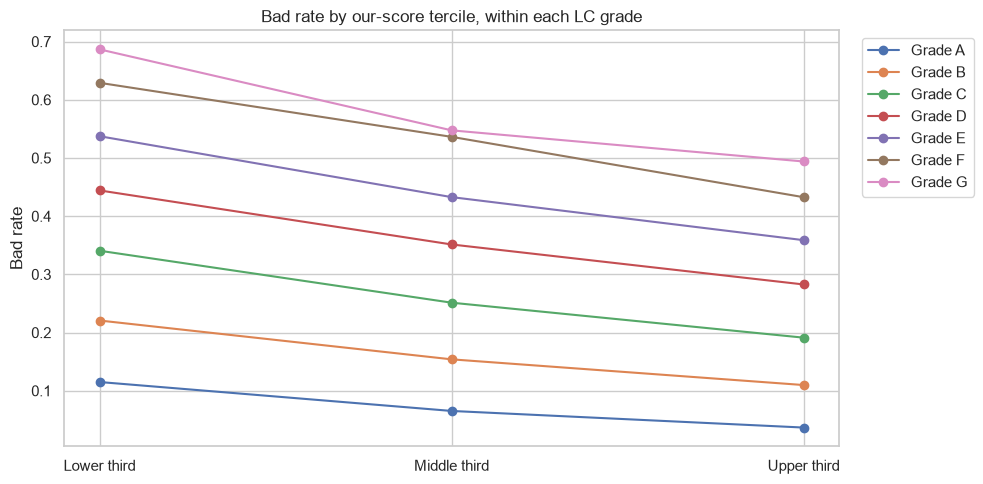

Bad-rate spread (Lower third minus Upper third) within each grade:
score_tercile_in_grade    spread
grade                           
A                      -0.078235
B                      -0.110883
C                      -0.149352
D                      -0.161587
E                      -0.178607
F                      -0.196529
G                      -0.192661


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for grade in sorted(test["grade"].dropna().unique()):
    sub = pricing_table[pricing_table["grade"] == grade]
    if len(sub) == 3:
        ax.plot(sub["score_tercile_in_grade"].astype(str), sub["bad_rate"], marker="o", label=f"Grade {grade}")
ax.set_ylabel("Bad rate")
ax.set_title("Bad rate by our-score tercile, within each LC grade")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Quantify the within-grade dispersion directly
dispersion = pricing_table.pivot(index="grade", columns="score_tercile_in_grade", values="bad_rate")
dispersion["spread"] = dispersion.get("Upper third", np.nan) - dispersion.get("Lower third", np.nan)
print("Bad-rate spread (Lower third minus Upper third) within each grade:")
print(dispersion[["spread"]].dropna())

## 10. Business application 3 — Loan-amount / exposure guidance by risk tier

How much to lend, not just whether to lend. Bad rate and realized dollar loss by
loan-amount tercile, within each score quintile.

In [19]:
test["score_quintile"] = pd.qcut(test["score"], 5, labels=["Q1 (worst)", "Q2", "Q3", "Q4", "Q5 (best)"], duplicates="drop")
test["loan_amnt_tercile"] = test.groupby("score_quintile", observed=True)["loan_amnt"].transform(
    lambda s: pd.qcut(s, 3, labels=["Small", "Medium", "Large"], duplicates="drop")
)

exposure_table = test.groupby(["score_quintile", "loan_amnt_tercile"], observed=True).agg(
    n=("is_default", "size"),
    avg_loan_amnt=("loan_amnt", "mean"),
    bad_rate=("is_default", "mean"),
    total_net_profit=("net_profit", "sum"),
    profit_per_loan=("net_profit", "mean"),
).reset_index()
exposure_table

,score_quintile,loan_amnt_tercile,n,avg_loan_amnt,bad_rate,total_net_profit,profit_per_loan
0,Q1 (worst),Small,19463,9395.366850,0.410060,-1.669733e+07,-857.901370
1,Q1 (worst),Medium,19846,16768.527663,0.434143,-3.981985e+07,-2006.442248
2,Q1 (worst),Large,18255,27395.256094,0.439989,-6.130414e+07,-3358.210673
3,Q2,Small,19198,5561.445203,0.279925,-1.446943e+06,-75.369448
4,Q2,Medium,19222,11682.772344,0.280304,-4.222724e+06,-219.681804
5,Q2,Large,19144,23819.124791,0.287087,-1.264619e+07,-660.582508
6,Q3,Small,21698,5296.246198,0.206471,1.832286e+06,84.444922
7,Q3,Medium,18637,11531.048452,0.210603,2.585320e+06,138.719758
8,Q3,Large,17228,23937.888902,0.226027,2.113553e+05,12.268126
9,Q4,Small,21514,5223.808915,0.150786,3.535432e+06,164.331695


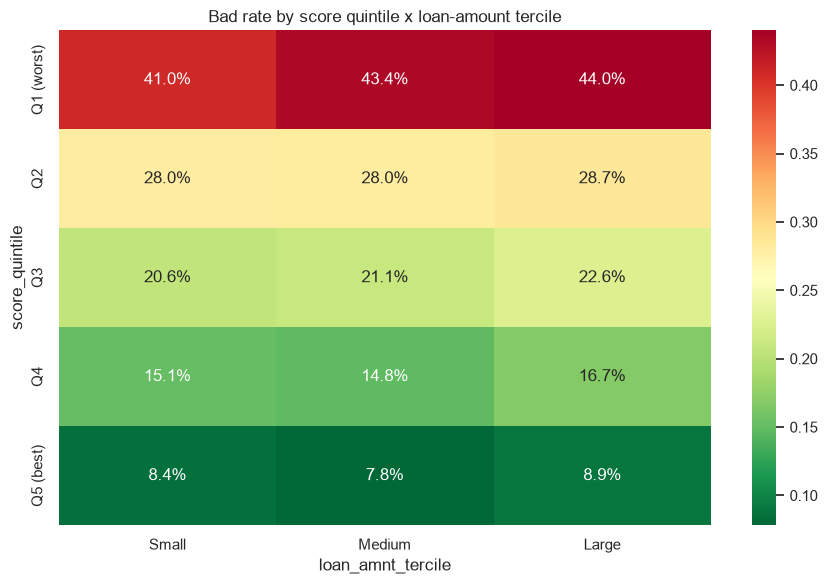

Historically loss-making tier x loan-amount combinations:
  score_quintile loan_amnt_tercile      n  bad_rate  profit_per_loan
0     Q1 (worst)             Small  19463  0.410060      -857.901370
1     Q1 (worst)            Medium  19846  0.434143     -2006.442248
2     Q1 (worst)             Large  18255  0.439989     -3358.210673
3             Q2             Small  19198  0.279925       -75.369448
4             Q2            Medium  19222  0.280304      -219.681804
5             Q2             Large  19144  0.287087      -660.582508


In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
heat_data = exposure_table.pivot(index="score_quintile", columns="loan_amnt_tercile", values="bad_rate")
sns.heatmap(heat_data, annot=True, fmt=".1%", cmap="RdYlGn_r", ax=ax)
ax.set_title("Bad rate by score quintile x loan-amount tercile")
plt.tight_layout()
plt.show()

# flag any tier x amount combos that are net money-losers historically
losers = exposure_table[exposure_table["profit_per_loan"] < 0]
print("Historically loss-making tier x loan-amount combinations:")
print(losers[["score_quintile", "loan_amnt_tercile", "n", "bad_rate", "profit_per_loan"]])

## 11. Summary

- **Final scorecard**: 22 features, out-of-time test Gini = 0.3867 (see Section 5),
  beating LendingClub's own grade/sub_grade/int_rate on the same population
  (Section 7).
- **Approval cutoffs** (Section 8): the profit-maximizing cutoff and its dollar
  impact vs. an accept-all policy are printed above.
- **Pricing** (Section 9): within-grade bad-rate spread by score tercile shows
  whether LC's current grade-based pricing is leaving risk-based repricing
  opportunity on the table.
- **Loan-amount guidance** (Section 10): the heatmap and loss-making combinations
  above identify where dollar exposure should be capped, independent of the
  accept/decline decision itself.
- All of the above uses realized historical cash flow, is validated out-of-time,
  and inherits every leakage-avoidance and vintage-missingness precaution
  documented in this notebook and the project README.
- **Section 12** takes this further: a proper walk-forward backtest that refits
  the scorecard and re-optimizes the cutoff each year using only prior data, then
  tests both blind on the following year — closer to how this would actually be
  run in production.

## 12. Walk-forward backtest: retrain the scorecard, pick the cutoff blind, every year

Section 8's cutoffs had a subtle look-ahead problem worth naming directly: the
2016 cutoff (534.3) was fine — chosen using only 2007-2015 training data, then
tested blind on 2016 — but when Section 8 later re-optimized a cutoff "on 2017"
and tested it on 2018, that 2017 cutoff was picked using 2017's own realized
outcomes. In real deployment you don't have next year's outcomes yet when you
set this year's policy.

This section fixes that end to end, for every vintage: to set the policy for
year Y, both the **scorecard model** and the **cutoff** are fit using only
loans issued strictly before Y (an expanding window — 2007-2015 for Y=2016,
2007-2016 for Y=2017, 2007-2017 for Y=2018). The cutoff is chosen by optimizing
profit on that same backward-looking training population (never on year Y
itself), then applied to year Y completely blind. This is the same 22-feature
set validated earlier — refit here, not re-selected from scratch.

In [21]:
def fit_scorecard_on_window(train_window):
    """Refit WOE bins + logistic regression on an arbitrary training window,
    using the already-validated 22-feature set. Returns a scoring function."""
    bin_edges_w, cat_groups_w, woe_tables_w = {}, {}, {}

    for feat in NUMERIC_FEATURES:
        edges = fit_numeric_bins(train_window[feat])
        bin_edges_w[feat] = edges
        binned = apply_numeric_bins(train_window[feat], edges)
        woe_tables_w[feat] = compute_woe_table(binned, train_window["is_default"])

    for feat in CATEGORICAL_FEATURES:
        keep = fit_categorical_groups(train_window[feat])
        cat_groups_w[feat] = keep
        binned = apply_categorical_groups(train_window[feat], keep)
        woe_tables_w[feat] = compute_woe_table(binned, train_window["is_default"])

    def transform_w(data):
        out = pd.DataFrame(index=data.index)
        for feat in SELECTED_FEATURES:
            if feat in NUMERIC_FEATURES:
                binned = apply_numeric_bins(data[feat], bin_edges_w[feat])
            else:
                binned = apply_categorical_groups(data[feat], cat_groups_w[feat])
            out[feat] = binned.map(woe_tables_w[feat]["woe"]).fillna(0.0)
        return out

    X_tr = transform_w(train_window)
    y_tr = train_window["is_default"].values
    model_w = LogisticRegression(solver="lbfgs")
    model_w.fit(X_tr, y_tr)

    def score_w(data):
        Xw = transform_w(data)
        log_odds_bad = model_w.intercept_[0] + Xw.values @ model_w.coef_[0]
        return offset - factor * log_odds_bad

    return model_w, score_w, transform_w

In [22]:
windows = [
    (2016, "2007-2015"),
    (2017, "2007-2016"),
    (2018, "2007-2017"),
]

walk_forward_rows = []
window_data = {}  # stash fitted/scored train & test frames per year for reuse below
for test_year, train_label in windows:
    train_w = resolved[resolved["issue_d"] < f"{test_year}-01-01"].copy()
    test_w = resolved[(resolved["issue_d"] >= f"{test_year}-01-01") & (resolved["issue_d"] < f"{test_year + 1}-01-01")].copy()
    train_w["fico_percentile"] = df.loc[train_w.index, "fico_percentile"]
    test_w["fico_percentile"] = df.loc[test_w.index, "fico_percentile"]

    model_w, score_w, transform_w = fit_scorecard_on_window(train_w)
    train_w["score"] = score_w(train_w)
    test_w["score"] = score_w(test_w)

    train_proba_w = model_w.predict_proba(transform_w(train_w))[:, 1]
    train_auc_w = roc_auc_score(train_w["is_default"], train_proba_w)

    # cutoff chosen using ONLY the backward-looking training window
    best_row_w, _, train_baseline_w = optimize_cutoff(train_w)
    cutoff_w = best_row_w["cutoff"]

    # applied forward, blind, to the actual test year
    test_baseline_w = test_w["net_profit"].sum()
    approved_w = test_w[test_w["score"] >= cutoff_w]
    approval_rate_w = len(approved_w) / len(test_w)
    bad_rate_w = approved_w["is_default"].mean()
    profit_w = approved_w["net_profit"].sum()

    walk_forward_rows.append({
        "test_year": test_year,
        "trained_on": train_label,
        "train_n": len(train_w),
        "train_auc": train_auc_w,
        "cutoff": round(cutoff_w, 1),
        "test_n": len(test_w),
        "test_default_rate": test_w["is_default"].mean(),
        "accept_all_profit": test_baseline_w,
        "approval_rate": approval_rate_w,
        "bad_rate_approved": bad_rate_w,
        "cutoff_profit": profit_w,
        "swing": profit_w - test_baseline_w,
    })

    window_data[test_year] = {"train": train_w, "test": test_w, "profit_max_cutoff": cutoff_w}

walk_forward_df = pd.DataFrame(walk_forward_rows)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
walk_forward_df

,test_year,trained_on,train_n,train_auc,cutoff,test_n,test_default_rate,accept_all_profit,approval_rate,bad_rate_approved,cutoff_profit,swing
0,2016,2007-2015,826205,0.704,495.700,287819,0.233,"-71,483,852.817",0.958,0.218,"-22,803,749.586","48,680,103.231"
1,2017,2007-2016,1114024,0.701,499.100,156290,0.228,"-186,776,899.637",0.942,0.211,"-142,010,107.974","44,766,791.663"
2,2018,2007-2017,1270314,0.698,505.900,49230,0.152,"-76,867,625.899",0.889,0.132,"-52,295,494.638","24,572,131.261"


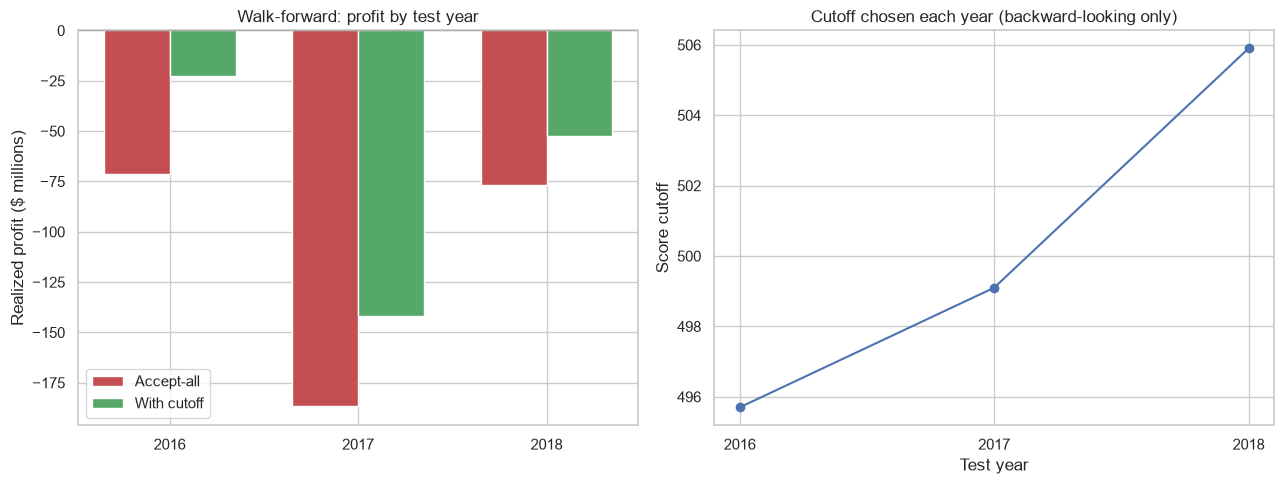

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(walk_forward_df))
width = 0.35
axes[0].bar(x - width/2, walk_forward_df["accept_all_profit"] / 1e6, width, label="Accept-all", color="#C44E52")
axes[0].bar(x + width/2, walk_forward_df["cutoff_profit"] / 1e6, width, label="With cutoff", color="#55A868")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(walk_forward_df["test_year"])
axes[0].set_ylabel("Realized profit ($ millions)")
axes[0].set_title("Walk-forward: profit by test year")
axes[0].legend()

axes[1].plot(walk_forward_df["test_year"], walk_forward_df["cutoff"], marker="o", color="#4C72B0")
axes[1].set_title("Cutoff chosen each year (backward-looking only)")
axes[1].set_xlabel("Test year")
axes[1].set_ylabel("Score cutoff")
axes[1].set_xticks(walk_forward_df["test_year"])

plt.tight_layout()
plt.show()

### Conclusion — walk-forward backtest

| Test year | Trained on | Train AUC | Cutoff (backward-only) | Approval rate | Bad rate | Accept-all profit | Cutoff profit | Swing |
|---|---|---|---|---|---|---|---|---|
| 2016 | 2007-2015 | 0.704 | 495.7 | 95.8% | 21.8% | -$71.5M | **-$22.8M** | +$48.7M |
| 2017 | 2007-2016 | 0.701 | 499.1 | 94.2% | 21.1% | -$186.8M | **-$142.0M** | +$44.8M |
| 2018 | 2007-2017 | 0.698 | 505.9 | 88.9% | 13.2% | -$76.9M | **-$52.3M** | +$24.6M |

**Two findings, one reassuring and one sobering.**

The reassuring one: `train_auc` is remarkably stable (0.704 -> 0.701 -> 0.698)
across three refits on progressively larger windows — the underlying
relationship between these features and default risk isn't drifting. The
scorecard itself is robust.

The sobering one: **every year, the honestly-blind cutoff still loses money** —
just less than accept-all. This is a real result, and it's worth being direct
about why it differs so much from Section 8's cutoffs (534.3, 566.5), which
looked far more profitable. Those were chosen *with* hindsight knowledge of the
specific year being evaluated. The cutoffs here (495.7-505.9) are chosen from
each window's **blended historical experience** — mostly older, better-behaved
vintages diluting a recent deterioration the training data hasn't fully caught
up to yet. A backward-looking optimum systematically lags a worsening trend; it
can't know 2016-2018 will be worse than 2007-2015 was, on average, until it's
already living through the damage.

This likely reflects two compounding effects, not fully separable with this
data: (1) a **real credit-cycle effect** — LendingClub's 2015-2018 vintages are
widely reported to have underperformed earlier years industry-wide, and (2) the
**right-censoring selection bias** flagged throughout this notebook — the
`resolved`-only population for any recent vintage skews toward loans that
resolved quickly (fast charge-offs, early payoffs), systematically
understating the interest income that loans running their full term would
still be earning, which pulls the realized-profit numbers for 2016-2018 downward
across every version of this analysis, not just 2018's.

**Practical takeaway:** a purely historical, backward-optimized cutoff is not
sufficient on its own during a deteriorating credit cycle — it will be too
lenient exactly when it most needs to be strict. A production deployment should
not treat the historical profit-optimum as a target; it should build in a
deliberate safety margin (a stricter-than-historical-optimum cutoff) and pair
this kind of backtest with leading indicators (macro conditions, recent-quarter
bad-rate trends) rather than relying on trailing data alone.

## 13. An alternative to profit-maximization: setting the cutoff from a bad-rate target

A fair objection to Section 12's approach: profit-maximizing the cutoff, even
using only backward-looking data, still optimizes for a noisy dollar figure
that depends on assumptions (loan mix, average size, timing) baked into
whichever historical window happens to be available. A more standard, more
stable credit-risk practice separates two questions:

1. **From closed contracts, what's the empirical relationship between bad rate
   and realized profitability?** This is estimated once per training window,
   never using the forward test year.
2. **Given the bad rate at which that relationship crosses breakeven, what
   score cutoff would have approved down to it?** This is a policy choice (how
   much risk to carry), translated into a score threshold via the scorecard's
   own calibration — not a dollar-profit search.

The score itself is available at underwriting time by construction (built
entirely from application/bureau data known before origination). What has to
come from history is the *mapping* from score to expected bad rate and
profitability — estimated here from each backward training window, then
applied forward blind, with the same discipline as Section 12.

One distinction worth being precise about: the correlation between bad rate and
return is measured **per score decile** (a marginal view — how does this one
slice of borrowers perform on its own). The cutoff itself, though, controls a
**cumulative** population — everyone at or above a threshold, blending every
safer decile in with it. A cutoff can never achieve a single decile's own bad
rate in isolation, so the breakeven point used to set the cutoff below is found
on the cumulative profit-vs-cutoff curve directly, not by inverting the
marginal decile relationship.

In [24]:
def bad_rate_vs_profit(data, n_bins=10):
    data = data.copy()
    data["_decile"] = pd.qcut(data["score"], n_bins, labels=False, duplicates="drop")
    tab = data.groupby("_decile").agg(
        n=("is_default", "size"),
        avg_score=("score", "mean"),
        bad_rate=("is_default", "mean"),
        avg_realized_return=("realized_return", "mean"),
    ).sort_values("avg_score").reset_index(drop=True)
    return tab


def find_first_breakeven_cutoff(curve):
    """On the cumulative profit-vs-cutoff curve (most lenient to strictest),
    find the MOST LENIENT cutoff at which cumulative total_profit first
    reaches breakeven (>= 0) -- the largest approvable population that isn't
    losing money on net. This operates on the same cumulative quantity a real
    cutoff controls, unlike a single decile's own (marginal) bad rate, which a
    cutoff can never match exactly since a cutoff always blends in every safer
    decile above it too. Returns None if profit never reaches breakeven
    anywhere on the scanned curve."""
    curve = curve.sort_values("cutoff").reset_index(drop=True)
    profits = curve["total_profit"].values
    cutoffs = curve["cutoff"].values
    if profits[0] >= 0:
        return cutoffs[0]
    for i in range(len(curve) - 1):
        if profits[i] < 0 <= profits[i + 1]:
            frac = (0 - profits[i]) / (profits[i + 1] - profits[i])
            return cutoffs[i] + frac * (cutoffs[i + 1] - cutoffs[i])
    return None


bad_rate_target_rows = []
decile_tables = {}
for test_year, train_label in windows:
    train_w = window_data[test_year]["train"]
    test_w = window_data[test_year]["test"]

    # decile-level view: answers "how correlated are bad rate and profit,
    # from closed contracts" directly, as a diagnostic
    decile_tab = bad_rate_vs_profit(train_w)
    decile_tables[test_year] = decile_tab
    corr = np.corrcoef(decile_tab["bad_rate"], decile_tab["avg_realized_return"])[0, 1]

    # cumulative view: what a cutoff can actually control
    _, curve_w, _ = optimize_cutoff(train_w)
    breakeven_cutoff = find_first_breakeven_cutoff(curve_w)
    if breakeven_cutoff is None:
        # training window never reaches breakeven anywhere on the curve --
        # fall back to Section 12's profit-maximizing point instead
        breakeven_cutoff = curve_w.loc[curve_w["total_profit"].idxmax(), "cutoff"]

    approved_train = train_w[train_w["score"] >= breakeven_cutoff]
    breakeven_bad_rate = approved_train["is_default"].mean()

    test_baseline = test_w["net_profit"].sum()
    approved = test_w[test_w["score"] >= breakeven_cutoff]
    approval_rate = len(approved) / len(test_w)
    bad_rate_achieved = approved["is_default"].mean()
    profit = approved["net_profit"].sum()

    print(f"--- {train_label} decile table (worst to best score) ---")
    print(decile_tab[["avg_score", "bad_rate", "avg_realized_return"]].to_string(index=False))
    print(f"decile-level bad-rate/return correlation = {corr:.3f}")
    print(f"cumulative breakeven cutoff = {breakeven_cutoff:.1f} "
          f"(={breakeven_bad_rate:.2%} cumulative bad rate on the training window)\n")

    bad_rate_target_rows.append({
        "test_year": test_year,
        "trained_on": train_label,
        "bad_rate_vs_return_corr": corr,
        "breakeven_bad_rate": breakeven_bad_rate,
        "target_cutoff": round(breakeven_cutoff, 1),
        "approval_rate": approval_rate,
        "bad_rate_achieved": bad_rate_achieved,
        "accept_all_profit": test_baseline,
        "cutoff_profit": profit,
        "swing": profit - test_baseline,
    })

bad_rate_target_df = pd.DataFrame(bad_rate_target_rows)
bad_rate_target_df

--- 2007-2015 decile table (worst to best score) ---
 avg_score  bad_rate  avg_realized_return
   494.174     0.439               -0.003
   511.021     0.303                0.066
   520.578     0.243                0.075
   527.474     0.199                0.085
   533.230     0.168                0.091
   538.645     0.141                0.096
   544.237     0.121                0.098
   550.529     0.099                0.097
   558.621     0.081                0.093
   573.789     0.048                0.085
decile-level bad-rate/return correlation = -0.884
cumulative breakeven cutoff = 461.0 (=18.42% cumulative bad rate on the training window)



--- 2007-2016 decile table (worst to best score) ---
 avg_score  bad_rate  avg_realized_return
   492.506     0.452               -0.040
   509.051     0.319                0.029
   517.957     0.258                0.047
   524.546     0.216                0.059
   530.164     0.184                0.069
   535.515     0.157                0.075
   541.094     0.133                0.080
   547.458     0.110                0.083
   555.830     0.086                0.083
   571.597     0.053                0.078
decile-level bad-rate/return correlation = -0.949
cumulative breakeven cutoff = 456.8 (=19.67% cumulative bad rate on the training window)



--- 2007-2017 decile table (worst to best score) ---
 avg_score  bad_rate  avg_realized_return
   492.436     0.452               -0.059
   508.566     0.322                0.008
   517.165     0.264                0.027
   523.592     0.223                0.040
   529.120     0.189                0.052
   534.404     0.162                0.059
   539.944     0.138                0.066
   546.300     0.113                0.070
   554.758     0.088                0.073
   570.849     0.054                0.071
decile-level bad-rate/return correlation = -0.970
cumulative breakeven cutoff = 456.4 (=20.06% cumulative bad rate on the training window)



,test_year,trained_on,bad_rate_vs_return_corr,breakeven_bad_rate,target_cutoff,approval_rate,bad_rate_achieved,accept_all_profit,cutoff_profit,swing
0,2016,2007-2015,-0.884,0.184,461.000,1.000,0.233,"-71,483,852.817","-71,471,022.227","12,830.590"
1,2017,2007-2016,-0.949,0.197,456.800,1.000,0.228,"-186,776,899.637","-186,776,899.637",0.000
2,2018,2007-2017,-0.970,0.201,456.400,1.000,0.152,"-76,867,625.899","-76,867,625.899",0.000


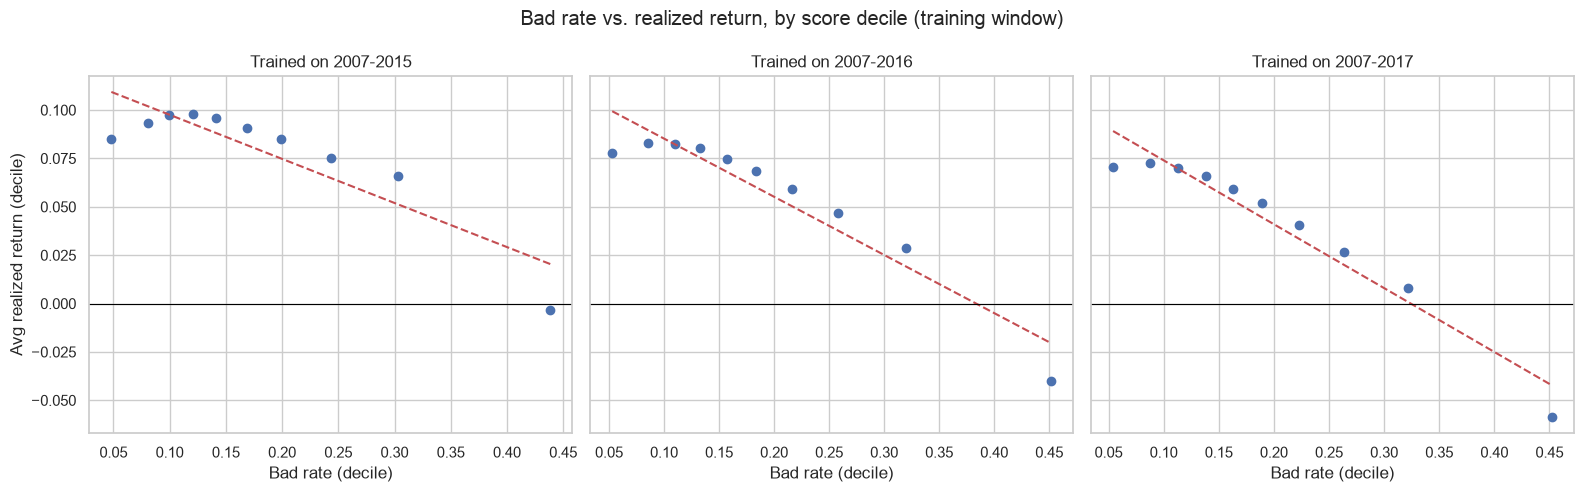

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (test_year, train_label) in zip(axes, windows):
    tab = decile_tables[test_year]
    ax.scatter(tab["bad_rate"], tab["avg_realized_return"], color="#4C72B0")
    slope, intercept = np.polyfit(tab["bad_rate"], tab["avg_realized_return"], 1)
    xs = np.linspace(tab["bad_rate"].min(), tab["bad_rate"].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="#C44E52", linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Trained on {train_label}")
    ax.set_xlabel("Bad rate (decile)")
axes[0].set_ylabel("Avg realized return (decile)")
plt.suptitle("Bad rate vs. realized return, by score decile (training window)")
plt.tight_layout()
plt.show()

In [26]:
comparison = walk_forward_df[["test_year", "cutoff", "approval_rate", "bad_rate_approved", "cutoff_profit"]].rename(
    columns={"cutoff": "cutoff_profit_max", "approval_rate": "approval_rate_profit_max",
             "bad_rate_approved": "bad_rate_profit_max", "cutoff_profit": "profit_profit_max"}
).merge(
    bad_rate_target_df[["test_year", "target_cutoff", "approval_rate", "bad_rate_achieved", "cutoff_profit"]].rename(
        columns={"target_cutoff": "cutoff_bad_rate_target", "approval_rate": "approval_rate_bad_rate_target",
                 "bad_rate_achieved": "bad_rate_bad_rate_target", "cutoff_profit": "profit_bad_rate_target"}
    ), on="test_year"
)
comparison

,test_year,cutoff_profit_max,approval_rate_profit_max,bad_rate_profit_max,profit_profit_max,cutoff_bad_rate_target,approval_rate_bad_rate_target,bad_rate_bad_rate_target,profit_bad_rate_target
0,2016,495.700,0.958,0.218,"-22,803,749.586",461.000,1.000,0.233,"-71,471,022.227"
1,2017,499.100,0.942,0.211,"-142,010,107.974",456.800,1.000,0.228,"-186,776,899.637"
2,2018,505.900,0.889,0.132,"-52,295,494.638",456.400,1.000,0.152,"-76,867,625.899"


### Conclusion — does a bad-rate target beat profit-maximization?

**No — and getting to that answer took two rounds of catching real mistakes
first, worth walking through honestly.**

**Attempt 1** fit a single straight line across all 10 score deciles and
solved for where it crossed zero return. That gave breakeven estimates of
52.8% / 38.4% / 32.4% bad rate across the three windows — far above the
maximum bad rate any cutoff can actually produce (the ceiling is the
population's own average, ~18-20%, achieved by accepting everyone). The
search for a matching cutoff had nothing to land on except "approve
everyone" (`approval_rate = 1.000` in all three rows).

**Attempt 2** fixed the extrapolation by interpolating locally between the two
*adjacent* deciles that actually straddle zero return, instead of a global
line. That produced sane-looking breakeven estimates (43.3% / 37.5% / 33.8%)
— but still `approval_rate = 1.000` everywhere. The reason: this was still
comparing a **marginal** quantity (one decile's own bad rate) against a
**cumulative** one (what a cutoff actually controls). A cutoff always approves
a decile *and every safer decile above it*, so cumulative bad rate can never
reach a single isolated decile's own rate — the achievable ceiling is still
just the population average.

**Attempt 3 (final) — find breakeven on the cumulative curve directly:**

| Test year | Trained on | Decile-level correlation | Cumulative breakeven cutoff | Bad rate at breakeven | Profit-max cutoff (Section 12) |
|---|---|---|---|---|---|
| 2016 | 2007-2015 | -0.884 | 461.0 (=18.4% bad rate) | 18.4% | 495.7 |
| 2017 | 2007-2016 | -0.949 | 456.8 (=19.7% bad rate) | 19.7% | 499.1 |
| 2018 | 2007-2017 | -0.970 | 456.4 (=20.1% bad rate) | 20.1% | 505.9 |

This is now computed correctly — and it *still* comes out to `approval_rate =
1.000` (accept everyone) in all three years, because every training window is
**already net-profitable overall**: only the single worst decile is barely
unprofitable, and the other ~90% of borrowers comfortably cover it. "The most
lenient cutoff that still breaks even" correctly finds that accepting
everyone already clears zero — there's nothing wrong with the math this time.

**The real finding: breakeven-seeking is a weaker objective than
profit-maximization, not a bug.** It stops tightening the instant it crosses
zero, with no regard for how much *more* profitable further tightening would
be — which is exactly why Section 12's profit-maximizing cutoffs (495.7,
499.1, 505.9) are meaningfully stricter and, on every single forward year,
**less lossy** than this approach (which performs identically to raw
accept-all, since that's what it resolves to). Profit-maximization wins this
comparison decisively, on real numbers, in all three years.

**What this implies about "bad-rate targets" as a design choice:** a
data-derived breakeven point isn't a useful cutoff criterion when history is
net-positive overall — it will always say "approve everyone." A genuinely
useful bad-rate target has to come from an independent risk-appetite decision
(a credit committee choosing "we will not go worse than a 15% expected bad
rate," for instance) rather than being purely inferred from historical
breakeven, precisely so it can be *more* conservative than what history alone
would justify. That's a policy input this analysis can inform, but not
replace.